In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

In [2]:
path_to_csv = 'data/results.csv'
working_directory = os.getcwd()
parent_directory = os.path.dirname(working_directory)
df = pd.read_csv(os.path.join(parent_directory, path_to_csv))

In [ ]:
print(len(df))
df.drop_duplicates(inplace=True)
print(len(df))


450
435


In [4]:
df.head()

,sequence_length,model_dimension,precision,forward_time,backward_time,implementation
0,128,16,torch.bfloat16,0.000473,0.001671,triton_kernel
1,128,16,torch.bfloat16,0.021015,0.002851,pytorch_naive
2,128,16,torch.bfloat16,0.012699,0.002580,pytorch_scaled_dot_product_attention
3,128,16,torch.float16,0.000141,0.002401,triton_kernel
4,128,16,torch.float16,0.010823,0.002450,pytorch_naive


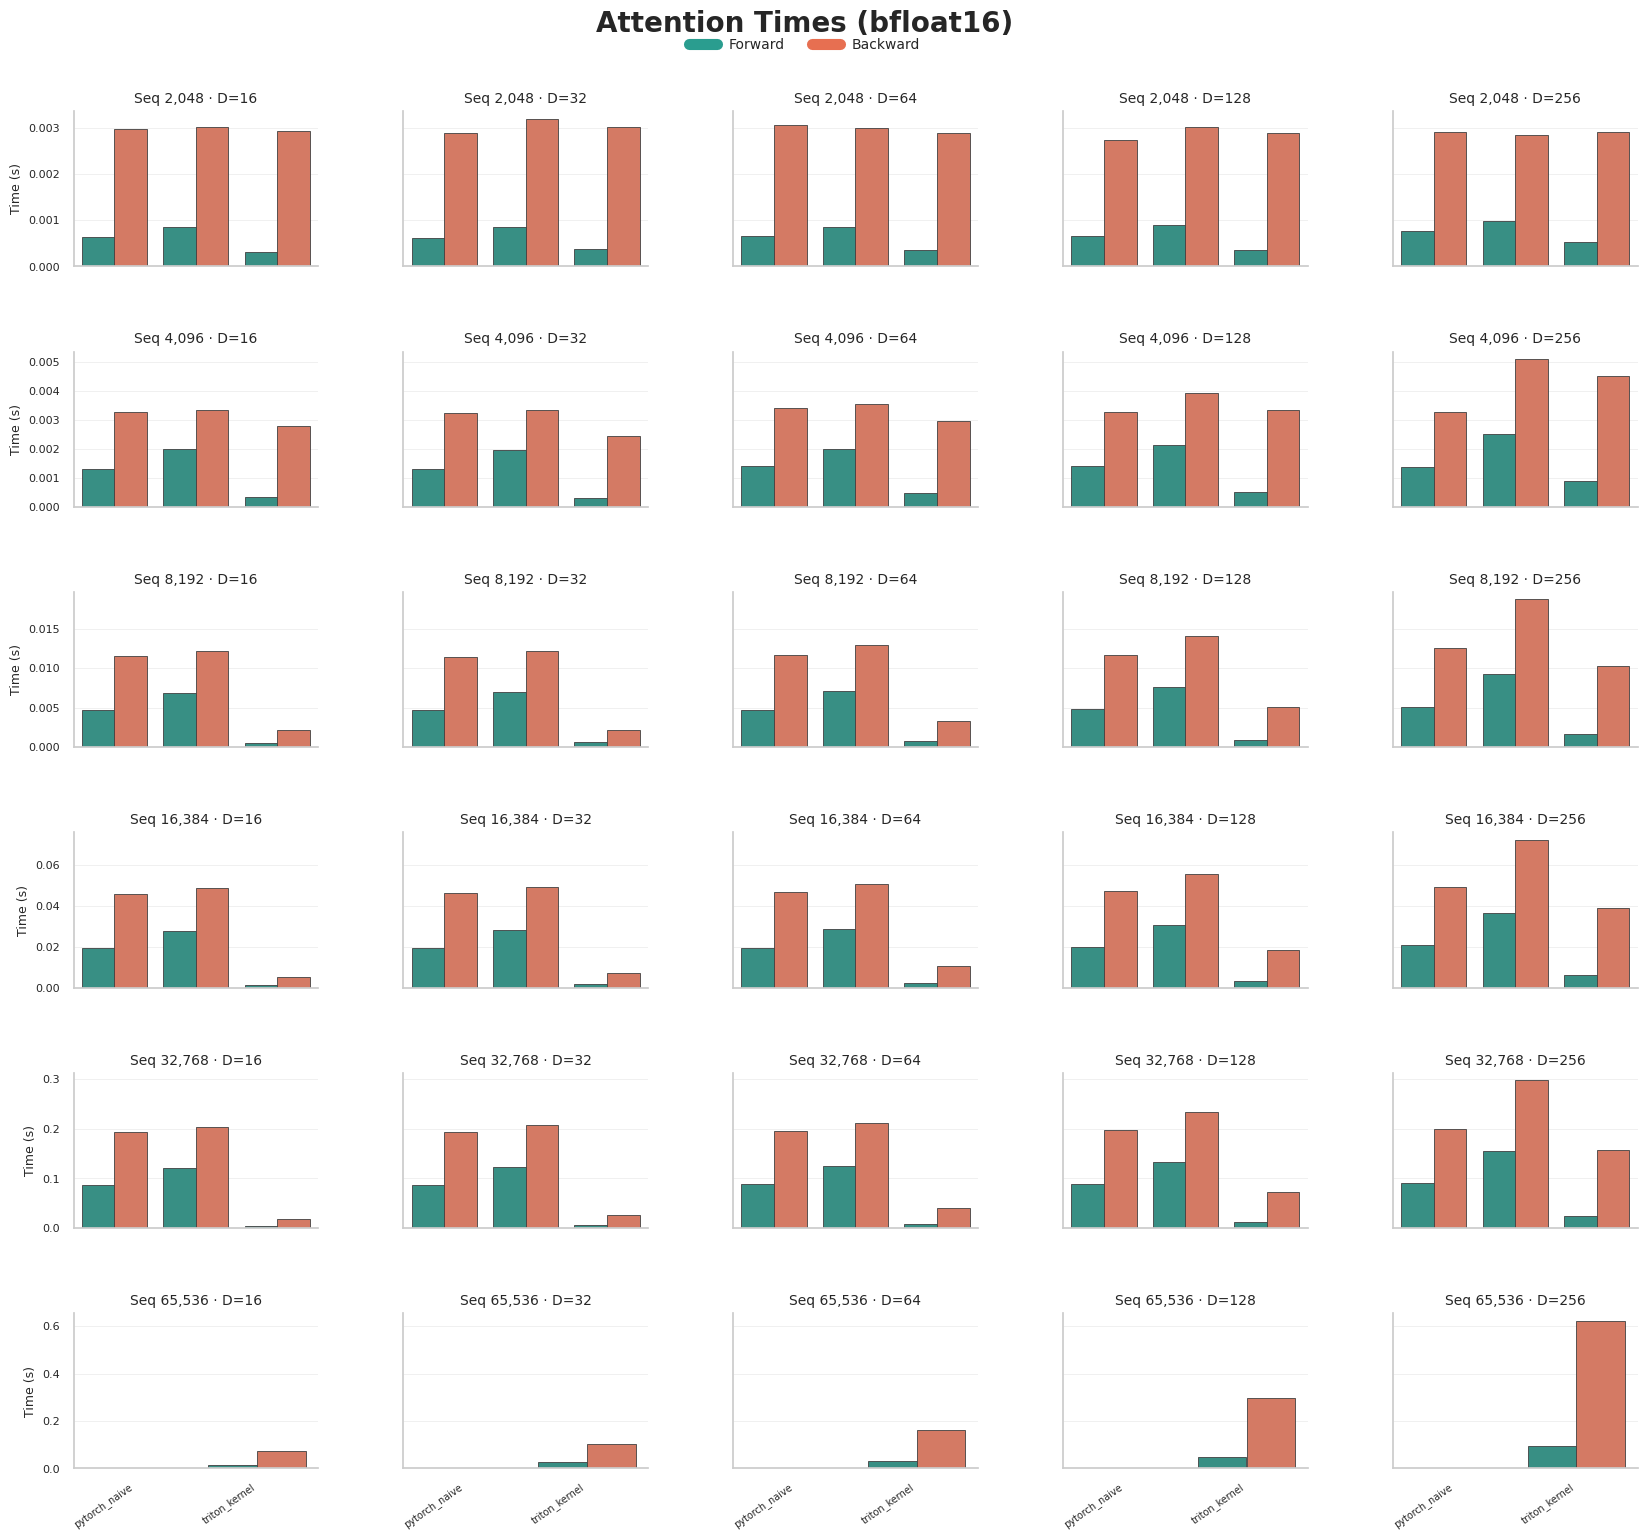

Saved: /workspace/Triton_flash_attention_2/notebooks/datatype times/bfloat16_times.png


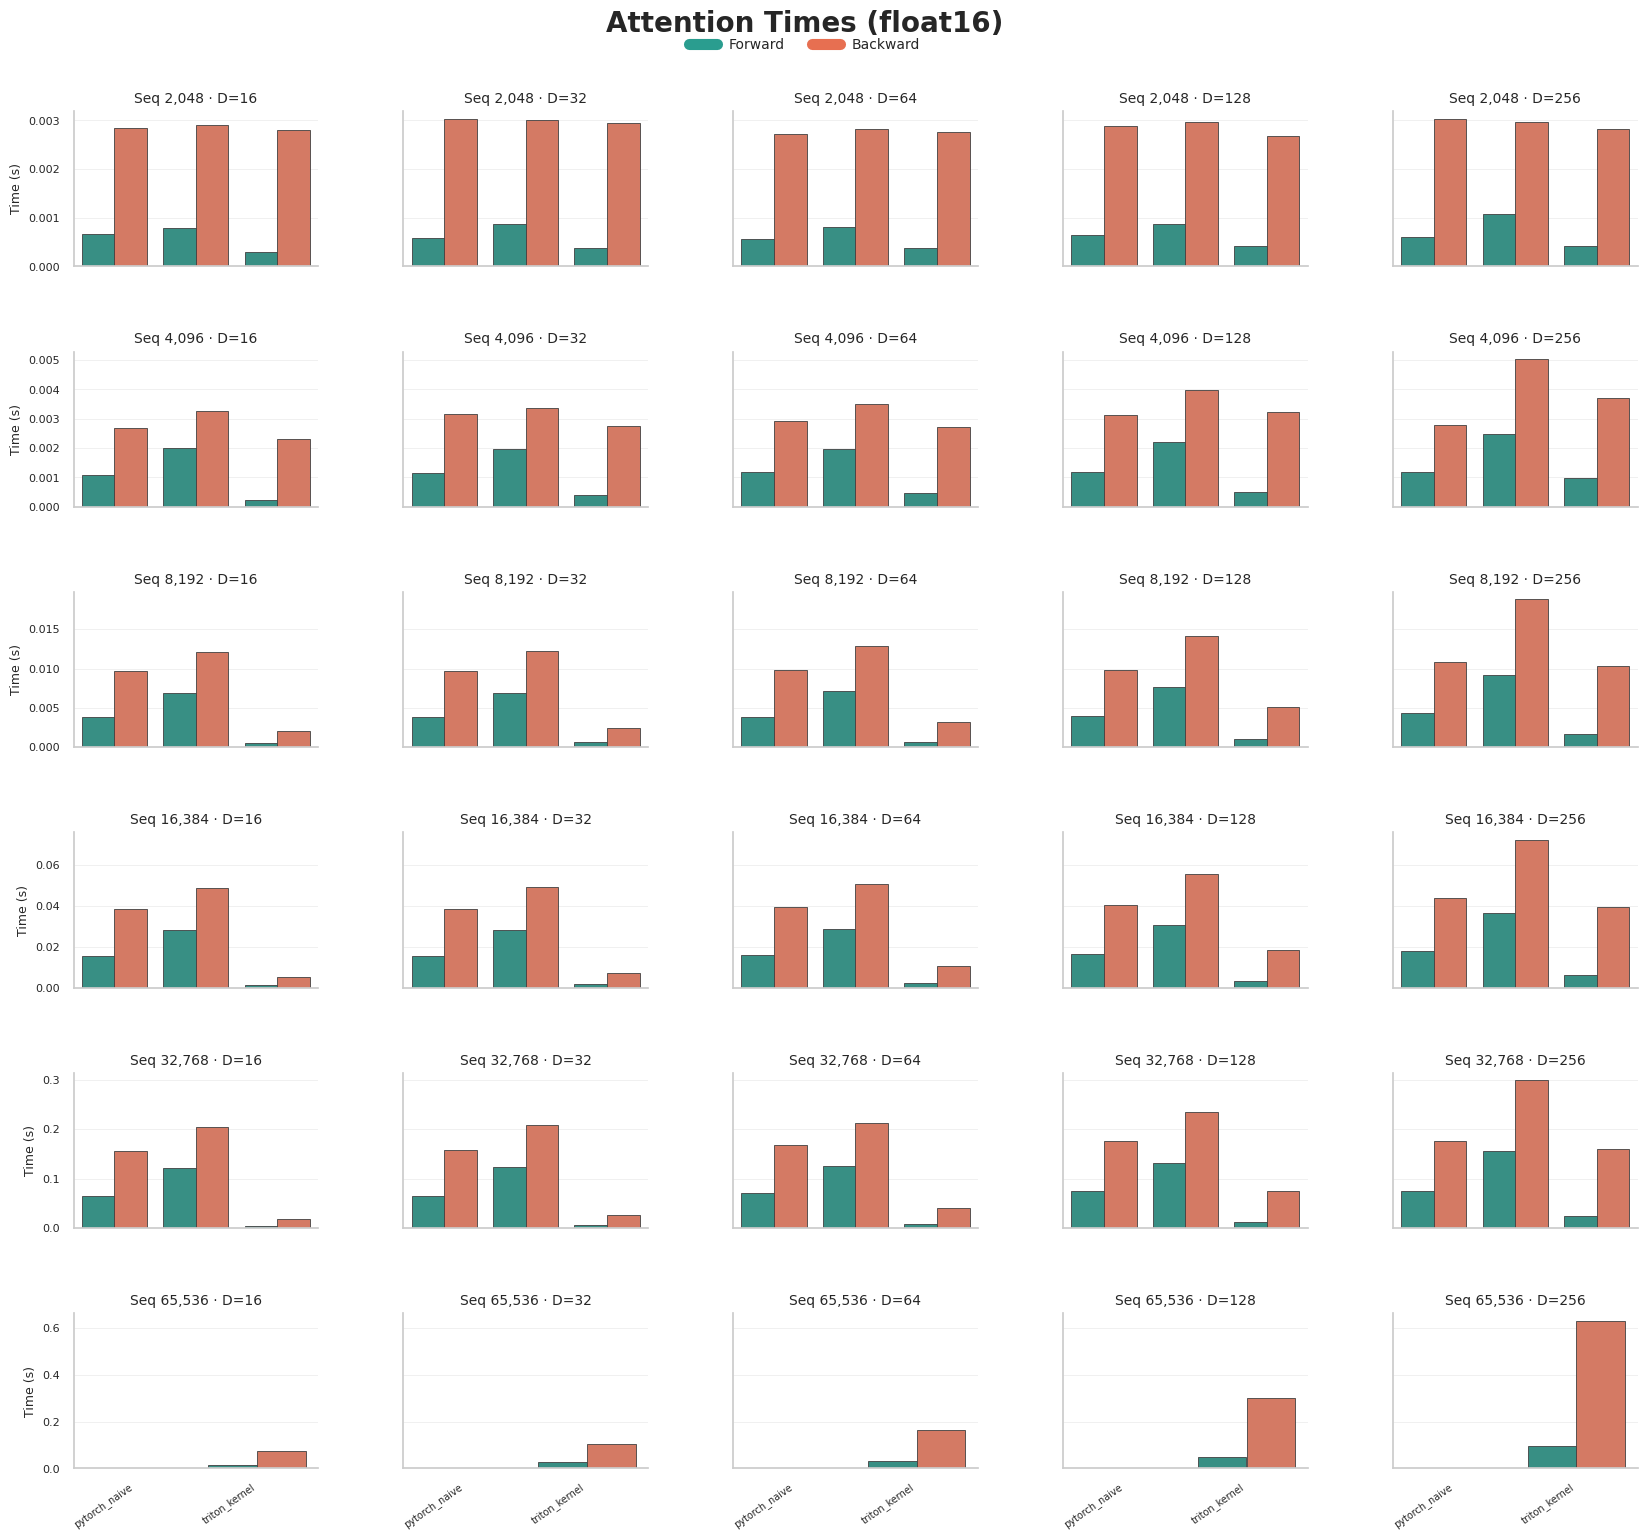

Saved: /workspace/Triton_flash_attention_2/notebooks/datatype times/float16_times.png


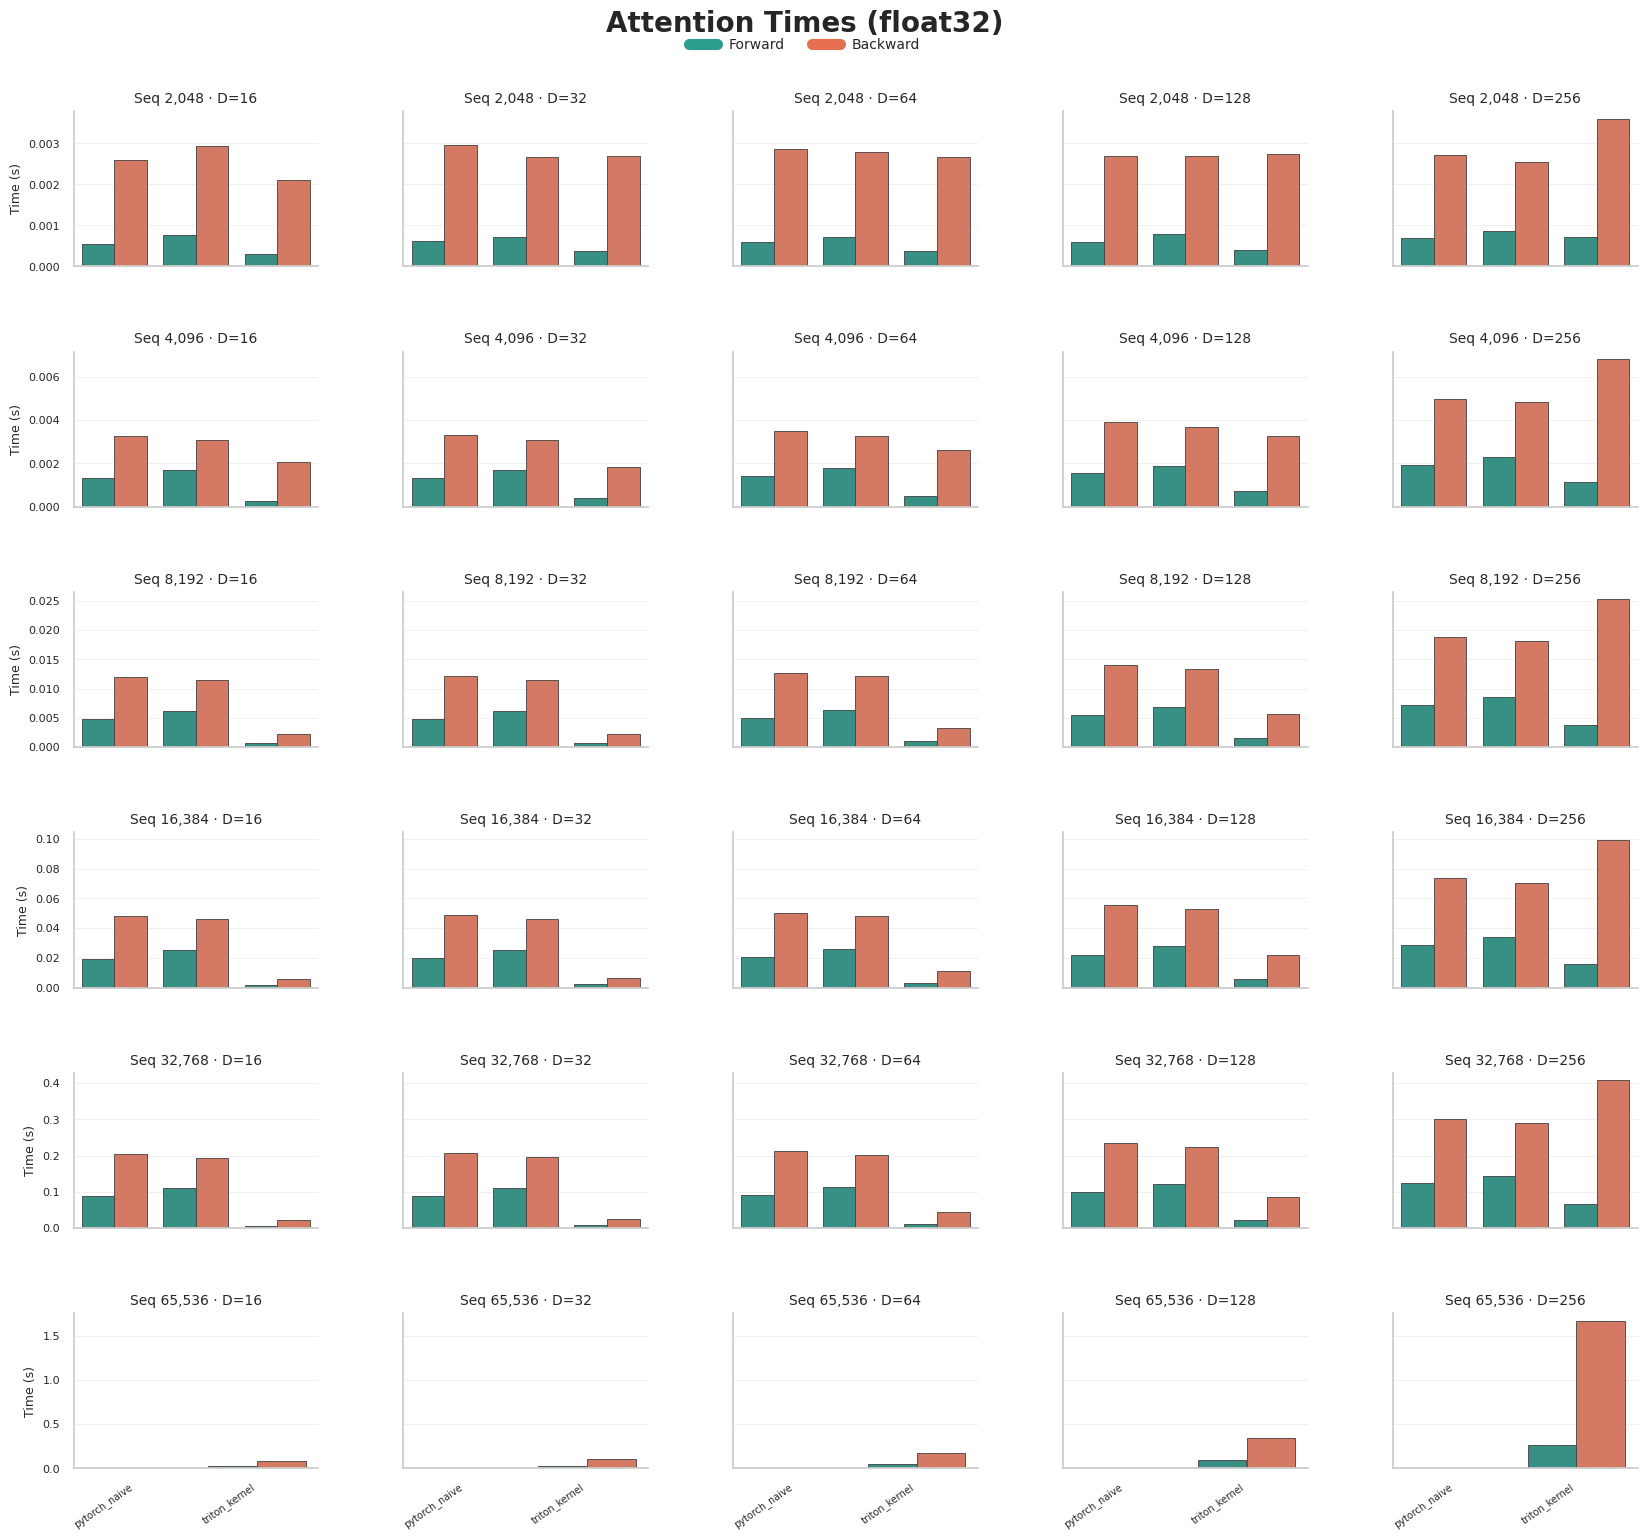

Saved: /workspace/Triton_flash_attention_2/notebooks/datatype times/float32_times.png


In [6]:
import seaborn as sns
from matplotlib.lines import Line2D

output_dir = os.path.join(working_directory, "datatype times")
os.makedirs(output_dir, exist_ok=True)

precisions = ["torch.bfloat16", "torch.float16", "torch.float32"]
precision_labels = {
    "torch.bfloat16": "bfloat16",
    "torch.float16": "float16",
    "torch.float32": "float32",
}
sequence_lengths = [2048, 4096, 8192, 16384, 32768, 65536]
model_dims = [16, 32, 64, 128, 256]

FORWARD_COLOR = "#2a9d8f"
BACKWARD_COLOR = "#e76f51"
HUE_ORDER = ["forward_time", "backward_time"]
HUE_LABELS = {"forward_time": "Forward", "backward_time": "Backward"}

sns.set_theme(style="whitegrid", context="notebook", font_scale=0.95)

n_rows = len(sequence_lengths)
n_cols = len(model_dims)

for precision in precisions:
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(3.4 * n_cols, 2.6 * n_rows),
        sharey="row",
        constrained_layout=False,
    )
    axes = np.atleast_2d(axes)
    fig.suptitle(
        f"Attention Times ({precision_labels[precision]})",
        fontsize=20,
        fontweight="bold",
        y=0.995,
    )

    for row_idx, seq_len in enumerate(sequence_lengths):
        for col_idx, model_dim in enumerate(model_dims):
            ax = axes[row_idx, col_idx]
            df_filtered = df[
                (df["sequence_length"] == seq_len)
                & (df["precision"] == precision)
                & (df["model_dimension"] == model_dim)
            ]

            if df_filtered.empty or "implementation" not in df_filtered.columns:
                ax.set_visible(False)
                continue

            barplot_df = (
                df_filtered.groupby("implementation", as_index=False)[
                    ["forward_time", "backward_time"]
                ].mean()
            )
            tidy = barplot_df.melt(
                id_vars="implementation",
                value_vars=["forward_time", "backward_time"],
                var_name="Type",
                value_name="Time",
            )
            tidy["Type"] = tidy["Type"].map(HUE_LABELS)

            sns.barplot(
                data=tidy,
                x="implementation",
                y="Time",
                hue="Type",
                hue_order=[HUE_LABELS[k] for k in HUE_ORDER],
                palette=[FORWARD_COLOR, BACKWARD_COLOR],
                edgecolor="0.25",
                linewidth=0.6,
                ax=ax,
                legend=False,
            )

            ax.set_title(f"Seq {seq_len:,} · D={model_dim}", fontsize=10, pad=6)
            ax.tick_params(axis="both", labelsize=8)
            ax.grid(axis="y", alpha=0.35, linewidth=0.6)

            if col_idx == 0:
                ax.set_ylabel("Time (s)", fontsize=9)
            else:
                ax.set_ylabel("")
            if row_idx == n_rows - 1:
                ax.set_xlabel("")
                ax.tick_params(axis="x", rotation=35, labelsize=7)
                for label in ax.get_xticklabels():
                    label.set_ha("right")
            else:
                ax.set_xlabel("")
                ax.set_xticklabels([])
            sns.despine(ax=ax, left=False)

    legend_handles = [
        Line2D([0], [0], color=FORWARD_COLOR, lw=8, label="Forward"),
        Line2D([0], [0], color=BACKWARD_COLOR, lw=8, label="Backward"),
    ]
    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.985),
        ncol=2,
        frameon=False,
        fontsize=10,
    )

    fig.subplots_adjust(
        left=0.07,
        right=0.99,
        top=0.93,
        bottom=0.06,
        hspace=0.55,
        wspace=0.35,
    )

    plot_filename = os.path.join(
        output_dir, f"{precision_labels[precision]}_times.png"
    )
    fig.savefig(plot_filename, dpi=200, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Saved: {plot_filename}")

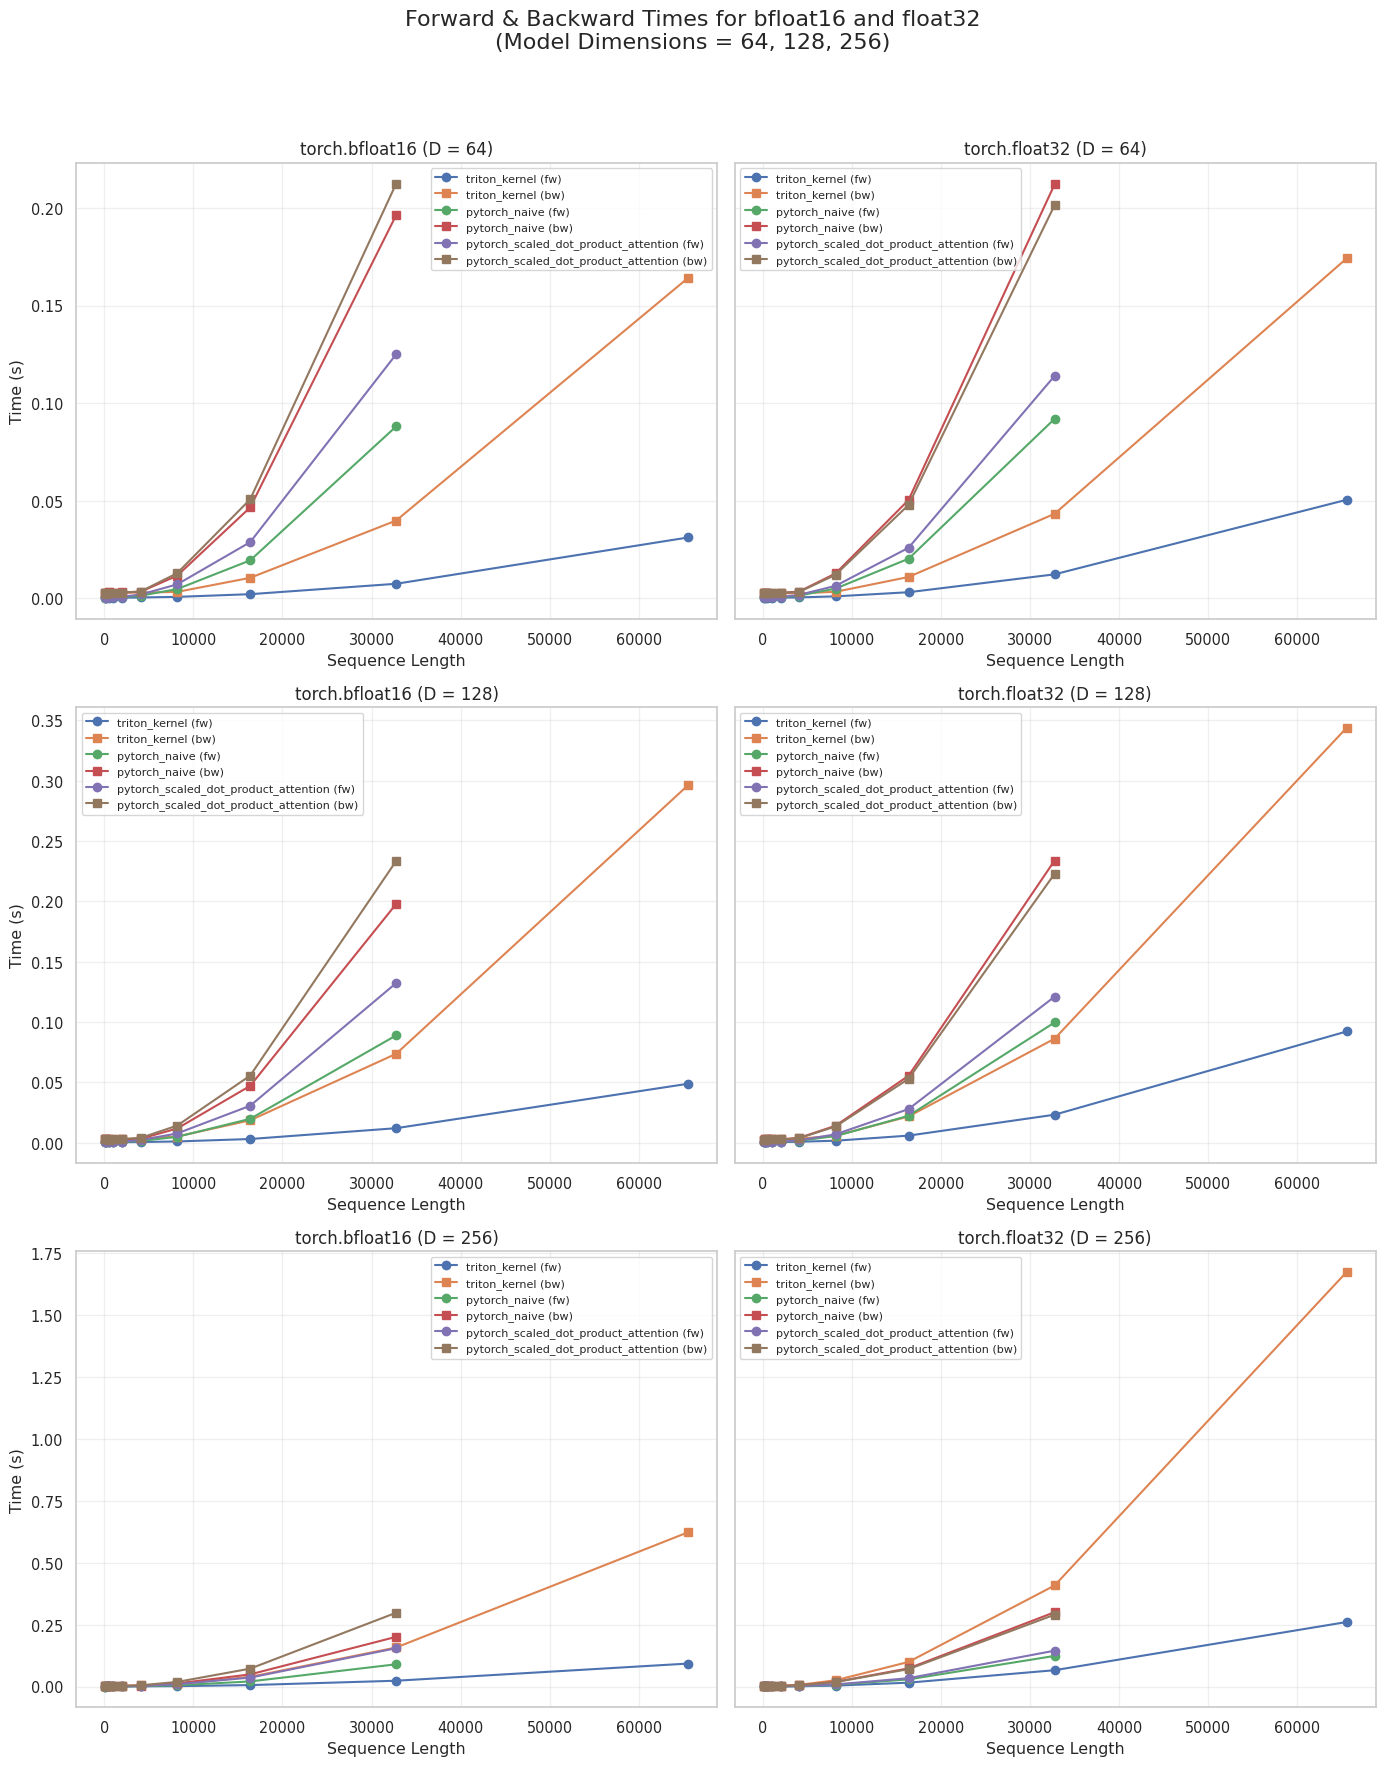

In [11]:
import matplotlib.pyplot as plt

# Model dimensions and precisions to plot
model_dims = [64, 128, 256]
plot_precisions = ['torch.bfloat16', 'torch.float32']

# Create subplots: rows for model dimensions, columns for precisions
fig, axes = plt.subplots(
    len(model_dims),
    len(plot_precisions),
    figsize=(14, 6 * len(model_dims)),
    sharey="row"
)

# If either dimension is 1, axes may not be 2D
if len(model_dims) == 1 and len(plot_precisions) == 1:
    axes = [[axes]]
elif len(model_dims) == 1:
    axes = [axes]
elif len(plot_precisions) == 1:
    axes = [[ax] for ax in axes]

for row_idx, model_dim in enumerate(model_dims):
    for col_idx, precision in enumerate(plot_precisions):
        ax = axes[row_idx][col_idx]
        df_filtered = df[
            (df["model_dimension"] == model_dim) &
            (df["precision"] == precision)
        ]
        seq_lens = sorted(df_filtered["sequence_length"].unique())
        implementations = df_filtered["implementation"].unique()

        for impl in implementations:
            df_impl = df_filtered[df_filtered["implementation"] == impl]
            ax.plot(
                df_impl["sequence_length"],
                df_impl["forward_time"], 
                marker='o',
                label=f"{impl} (fw)"
            )
            ax.plot(
                df_impl["sequence_length"],
                df_impl["backward_time"], 
                marker='s',
                label=f"{impl} (bw)"
            )
            
        ax.set_title(f"{precision} (D = {model_dim})", fontsize=12)
        ax.set_xlabel("Sequence Length")
        if col_idx == 0:
            ax.set_ylabel("Time (s)")
        else:
            ax.set_ylabel("")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)

fig.suptitle("Forward & Backward Times for bfloat16 and float32\n(Model Dimensions = 64, 128, 256)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
fig.savefig("forward_backward_times.png", dpi=200, bbox_inches="tight", facecolor="white")